In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import math
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

load data

In [2]:
# Load the dataset
df = pd.read_csv('DM1_games_clean.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (21925, 42)


In [3]:
# Display first few rows
df.head()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [4]:
# Get column info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21925 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            21925 non-null  float64
 9   LanguageEase         21925 non-null  float64
 10  GoodPlayers          21925 non-null  object 
 11  NumOwned             21925 non-null  int64  
 12  NumWant              21925 non-null  int64  
 13  NumWish              21925 non-null  int64  
 14  NumWeightVotes       21925 non-null  int64  
 15  ComMinPlaytime       21925 non-null 

In [5]:
# Statistical summary
df.describe()

,BGGId,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,NumOwned,NumWant,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
count,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,...,21925.000000,21925.000000,21925.000000,21925.00000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000
mean,117652.663216,2003.197218,2.027568,2.226591,2.009624,5.713615,10.003284,195.380014,1467.848164,41.690946,...,21295.352201,21062.680274,0.055827,0.10577,0.161003,0.105633,0.013820,0.050855,0.029190,0.040182
std,104628.721777,100.693040,0.792486,0.794279,0.688112,15.013089,2.826952,205.294531,5294.120574,117.255229,...,3637.139987,4219.776597,0.229592,0.30755,0.367542,0.307374,0.116745,0.219707,0.168344,0.196391
min,1.000000,-3500.000000,1.000000,1.100100,1.000000,0.000000,2.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12346.000000,2002.000000,1.360000,1.567900,2.000000,4.000000,8.000000,46.000000,150.000000,3.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,105305.000000,2011.000000,1.968800,2.128000,2.000000,4.000000,10.000000,138.000000,320.000000,9.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,206169.000000,2017.000000,2.525200,2.737700,2.000000,6.000000,11.600000,269.000000,899.000000,28.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,349161.000000,2021.000000,5.000000,5.213200,10.000000,999.000000,21.000000,1757.000000,166497.000000,2031.000000,...,21926.000000,21926.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


check for missing values

In [6]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Missing values found:")
    print(missing)
else:
    print("No missing values found!")

No missing values found!


check target variable distribution

In [7]:
# Check the distribution of our target variable 'Rating'
print("Rating distribution:")
print(df['Rating'].value_counts())
print("\nRating percentages:")
print(df['Rating'].value_counts(normalize=True) * 100)

Rating distribution:
Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64

Rating percentages:
Rating
Medium    43.986317
Low       33.044470
High      22.969213
Name: proportion, dtype: float64


let's visualize our target variable

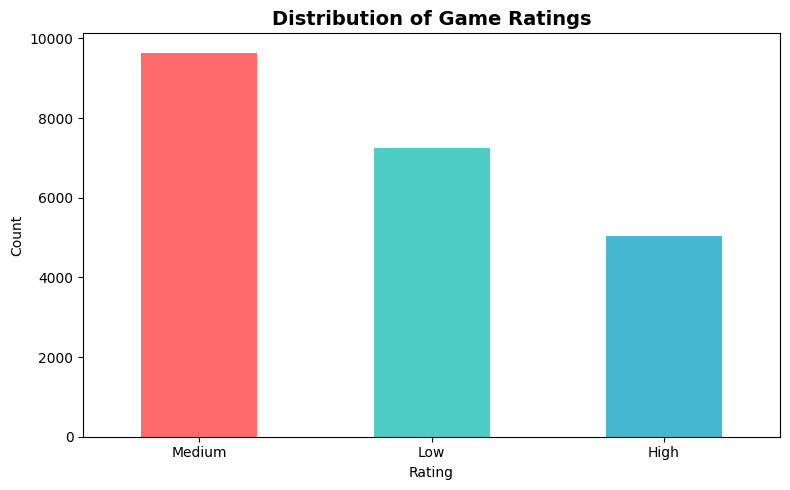

In [8]:
# Visualize rating distribution
plt.figure(figsize=(8, 5))
df['Rating'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Distribution of Game Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:10]}...")  # Show first 10
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (37): ['BGGId', 'YearPublished', 'GameWeight', 'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'NumOwned', 'NumWant']...

Categorical columns (5): ['Name', 'Description', 'GoodPlayers', 'ImagePath', 'Rating']


correlation matirx

In [10]:
# Calculate correlation matrix for numeric features (excluding BGGId which is just an ID)
numeric_features = [col for col in numeric_cols if col != 'BGGId']
correlation_matrix = df[numeric_features].corr()

# Find highly correlated pairs (correlation > 0.8 or < -0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("Highly correlated feature pairs (|correlation| > 0.8):")
    corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(corr_df)
else:
    print("No highly correlated features found!")

Highly correlated feature pairs (|correlation| > 0.8):
              Feature 1       Feature 2  Correlation
0            GameWeight       ComWeight     0.997383
2              NumOwned  NumUserRatings     0.985474
3               NumWant         NumWish     0.939758
5        NumWeightVotes  NumUserRatings     0.917162
1              NumOwned  NumWeightVotes     0.874817
6        ComMinPlaytime  ComMaxPlaytime     0.854679
4               NumWish  NumUserRatings     0.814348
12        Rank:wargames         Cat:War    -0.998480
7    Rank:strategygames    Cat:Strategy    -0.999415
9      Rank:familygames      Cat:Family    -0.999421
10        Rank:thematic    Cat:Thematic    -0.999854
8        Rank:abstracts    Cat:Abstract    -0.999880
14  Rank:childrensgames   Cat:Childrens    -0.999927
13      Rank:partygames       Cat:Party    -0.999962
11             Rank:cgs         Cat:CGS    -0.999992


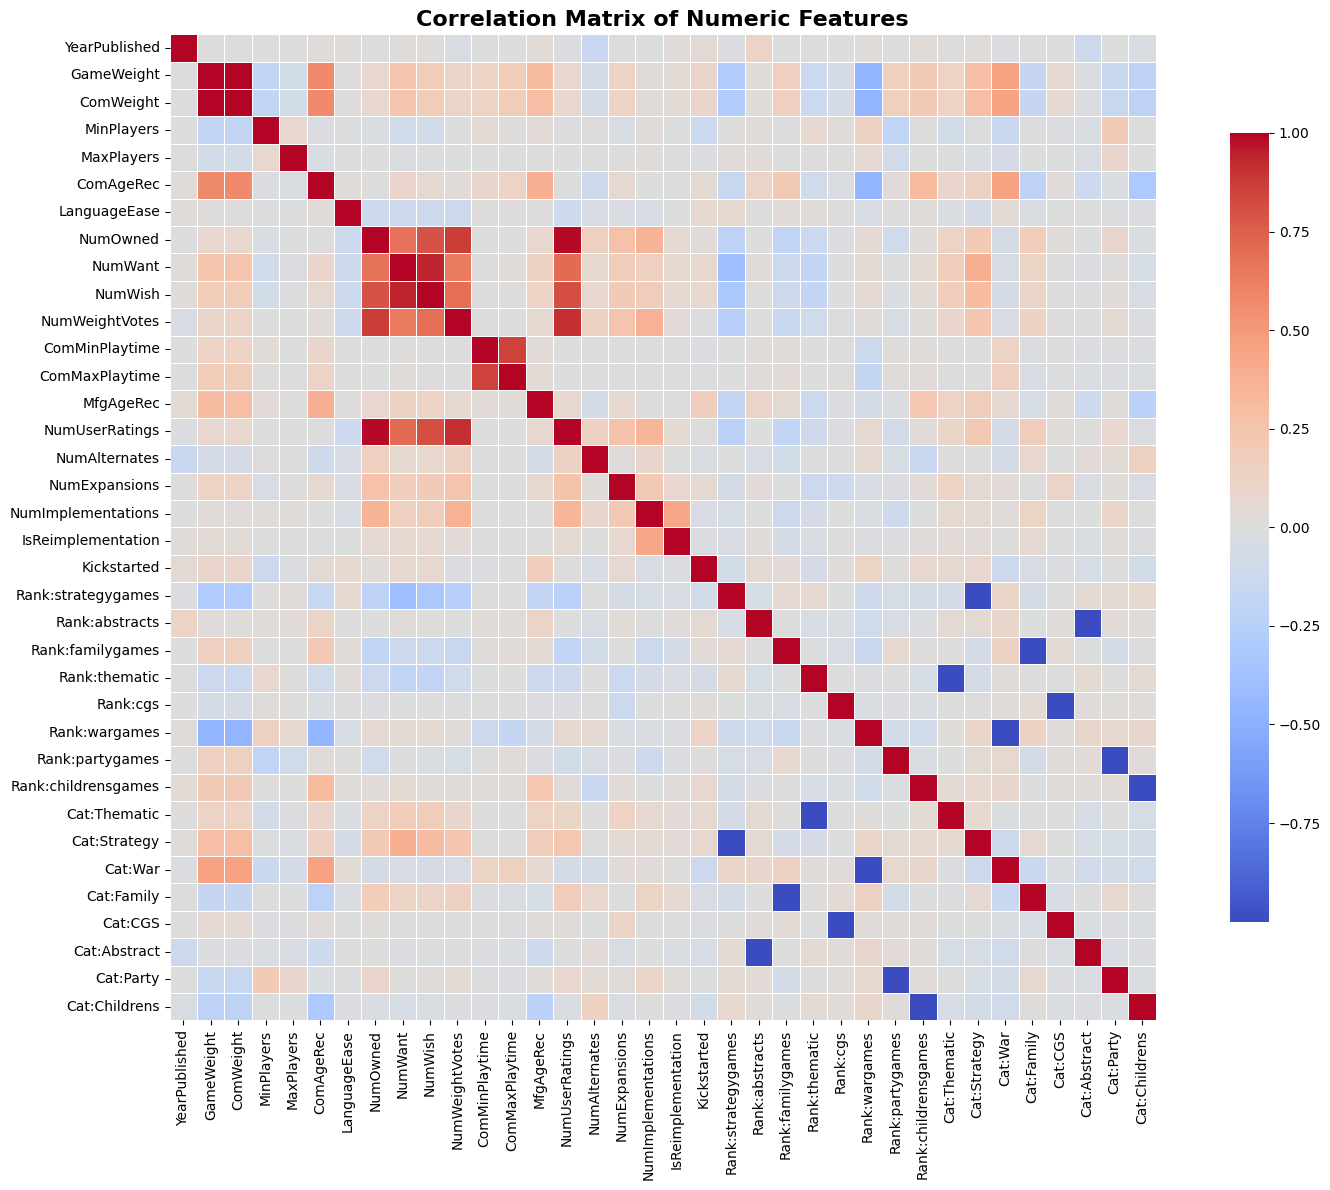

In [11]:
# Create correlation heatmap for top features
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

check the variance in features

In [12]:
# Check for low variance features
from sklearn.feature_selection import VarianceThreshold

# Calculate variance for numeric features
variances = df[numeric_features].var().sort_values()
print("Features with lowest variance:")
print(variances.head(10))
print("\nFeatures with highest variance:")
print(variances.tail(10))

Features with lowest variance:
Cat:CGS               0.013629
Cat:Party             0.028340
Cat:Childrens         0.038570
Cat:Abstract          0.048271
Cat:Thematic          0.052712
Cat:Family            0.094479
Cat:Strategy          0.094587
IsReimplementation    0.103133
Kickstarted           0.129833
Cat:War               0.135087
dtype: float64

Features with highest variance:
Rank:cgs               6.461936e+06
Rank:partygames        1.322879e+07
NumUserRatings         1.324000e+07
Rank:childrensgames    1.780651e+07
Rank:abstracts         2.204463e+07
Rank:thematic          2.395054e+07
NumOwned               2.802771e+07
Rank:familygames       4.079491e+07
Rank:strategygames     4.082717e+07
Rank:wargames          5.506985e+07
dtype: float64


Based on correlation analysis, let's identify which features to drop
We'll keep one from each highly correlated pair and drop the other

Looking at the correlation results, we need to decide which to keep:
1. GameWeight vs ComWeight (very similar): Keep ComWeight (more complete)
2. NumOwned vs NumUserRatings (both measure popularity): Keep NumOwned (more direct)


In [13]:
# 1. Drop ALL Rank features - they're perfectly correlated with Cat features (correlation ~-0.999)
rank_features = [col for col in df.columns if col.startswith('Rank:')]

# 2. Drop redundant pairs
redundant_features = [
    'GameWeight',  # Keeping ComWeight instead
    'NumUserRatings',  # Keeping NumOwned instead
    'NumWish',  # Keeping NumWant (NumWant vs NumWish correlation = 0.94)
    'NumWeightVotes',  # Keeping NumOwned (NumOwned vs NumWeightVotes = 0.87)
    'ComMaxPlaytime',  # Keeping ComMinPlaytime (correlation = 0.85)
]

# 3. Drop low variance category features (< 0.05)
low_variance_features = [
    'Cat:CGS',       # variance = 0.013
    'Cat:Party',     # variance = 0.028
    'Cat:Childrens', # variance = 0.038
    'Cat:Abstract',  # variance = 0.048
    'Cat:Thematic',  # variance = 0.052 - also perfectly correlated with Rank:thematic
]

# 4. Drop ID and text columns (we'll handle text in feature engineering)
non_feature_cols = ['BGGId', 'Name', 'Description']

# Combine all features to drop
features_to_drop = rank_features + redundant_features + low_variance_features + non_feature_cols

print(f"Total features to drop: {len(features_to_drop)}")
print(f"\nBreakdown:")
print(f"  - Rank features: {len(rank_features)} -> {rank_features}")
print(f"  - Redundant features: {len(redundant_features)} -> {redundant_features}")
print(f"  - Low variance features: {len(low_variance_features)} -> {low_variance_features}")
print(f"  - Non-feature columns: {len(non_feature_cols)} -> {non_feature_cols}")

Total features to drop: 21

Breakdown:
  - Rank features: 8 -> ['Rank:strategygames', 'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames']
  - Redundant features: 5 -> ['GameWeight', 'NumUserRatings', 'NumWish', 'NumWeightVotes', 'ComMaxPlaytime']
  - Low variance features: 5 -> ['Cat:CGS', 'Cat:Party', 'Cat:Childrens', 'Cat:Abstract', 'Cat:Thematic']
  - Non-feature columns: 3 -> ['BGGId', 'Name', 'Description']


In [14]:
# Create a clean dataset
df_clean = df.drop(columns=features_to_drop)

print(f"Original dataset: {df.shape}")
print(f"Cleaned dataset: {df_clean.shape}")
print(f"\nRemaining columns: {df_clean.columns.tolist()}")

Original dataset: (21925, 42)
Cleaned dataset: (21925, 21)

Remaining columns: ['YearPublished', 'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'GoodPlayers', 'NumOwned', 'NumWant', 'ComMinPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'IsReimplementation', 'Kickstarted', 'ImagePath', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Rating']


In [15]:
# Check correlations again after dropping redundant features
numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix_clean = df_clean[numeric_cols_clean].corr()

# Check for high correlations again
high_corr_pairs_clean = []
for i in range(len(correlation_matrix_clean.columns)):
    for j in range(i+1, len(correlation_matrix_clean.columns)):
        if abs(correlation_matrix_clean.iloc[i, j]) > 0.8:
            high_corr_pairs_clean.append({
                'Feature 1': correlation_matrix_clean.columns[i],
                'Feature 2': correlation_matrix_clean.columns[j],
                'Correlation': correlation_matrix_clean.iloc[i, j]
            })

if high_corr_pairs_clean:
    print("Still have highly correlated features:")
    print(pd.DataFrame(high_corr_pairs_clean))
else:
    print("✓ No highly correlated features remaining (|correlation| > 0.8)")
    print("Ready to proceed with modeling!")

✓ No highly correlated features remaining (|correlation| > 0.8)
Ready to proceed with modeling!


separate feautures and target

In [16]:
# Separate features (X) and target (y)
X = df_clean.drop('Rating', axis=1)
y = df_clean['Rating']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")

Features shape: (21925, 20)
Target shape: (21925,)

Features: ['YearPublished', 'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'GoodPlayers', 'NumOwned', 'NumWant', 'ComMinPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'IsReimplementation', 'Kickstarted', 'ImagePath', 'Cat:Strategy', 'Cat:War', 'Cat:Family']


encode our target

In [17]:
# Encode the target variable (Low=0, Medium=1, High=2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original classes:", label_encoder.classes_)
print("Encoded mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} -> {i}")

print(f"\nClass distribution (encoded):")
unique, counts = np.unique(y_encoded, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Class {val} ({label_encoder.classes_[val]}): {count} ({count/len(y_encoded)*100:.1f}%)")

Original classes: ['High' 'Low' 'Medium']
Encoded mapping:
  High -> 0
  Low -> 1
  Medium -> 2

Class distribution (encoded):
  Class 0 (High): 5036 (23.0%)
  Class 1 (Low): 7245 (33.0%)
  Class 2 (Medium): 9644 (44.0%)


handle imagepath and good players

In [19]:
# Check for any non-numeric columns
print("Checking data types:")
print(X.dtypes)
print("\n" + "="*50)

# Check which non-numeric columns we have
non_numeric = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nNon-numeric columns: {non_numeric}")

# Check GoodPlayers specifically
if 'GoodPlayers' in X.columns:
    print("\nGoodPlayers sample values:")
    print(X['GoodPlayers'].head(20))
    print(f"GoodPlayers unique values count: {X['GoodPlayers'].nunique()}")

# Check ImagePath if it exists
if 'ImagePath' in X.columns:
    print("\nImagePath sample values:")
    print(X['ImagePath'].head(5))

# Drop all non-numeric columns
columns_to_drop = non_numeric
if columns_to_drop:
    X = X.drop(columns_to_drop, axis=1)
    print(f"\n✓ Dropped columns: {columns_to_drop}")
else:
    print("\n✓ No non-numeric columns to drop")

print(f"\nFeatures shape after cleanup: {X.shape}")
print(f"Remaining columns: {X.columns.tolist()}")

# Verify all remaining columns are numeric
print(f"\n✓ All remaining columns are numeric: {X.dtypes.apply(lambda x: x.kind in 'biufc').all()}")

Checking data types:
YearPublished           int64
ComWeight             float64
MinPlayers              int64
MaxPlayers              int64
ComAgeRec             float64
LanguageEase          float64
GoodPlayers            object
NumOwned                int64
NumWant                 int64
ComMinPlaytime          int64
MfgAgeRec               int64
NumAlternates           int64
NumExpansions           int64
NumImplementations      int64
IsReimplementation      int64
Kickstarted             int64
ImagePath              object
Cat:Strategy            int64
Cat:War                 int64
Cat:Family              int64
dtype: object


Non-numeric columns: ['GoodPlayers', 'ImagePath']

GoodPlayers sample values:
0     []
1     []
2     []
3     []
4     []
5     []
6     []
7     []
8     []
9     []
10    []
11    []
12    []
13    []
14    []
15    []
16    []
17    []
18    []
19    []
Name: GoodPlayers, dtype: object
GoodPlayers unique values count: 78

ImagePath sample values:
0    https

train-test split

In [20]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Keep class distribution consistent
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Class {val} ({label_encoder.classes_[val]}): {count} ({count/len(y_train)*100:.1f}%)")

Training set size: 17540 samples
Testing set size: 4385 samples

Training set class distribution:
  Class 0 (High): 4029 (23.0%)
  Class 1 (Low): 5796 (33.0%)
  Class 2 (Medium): 7715 (44.0%)


features scaling

In [21]:
# Scale features using StandardScaler (important for KNN and other distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")
print(f"\nFeature means after scaling (should be ~0):")
print(np.mean(X_train_scaled, axis=0)[:5])  # Show first 5
print(f"\nFeature stds after scaling (should be ~1):")
print(np.std(X_train_scaled, axis=0)[:5])  # Show first 5

✓ Features scaled using StandardScaler
Training set shape: (17540, 18)
Testing set shape: (4385, 18)

Feature means after scaling (should be ~0):
[-4.85713079e-16  4.63837761e-16  2.44274384e-16 -2.43059089e-17
 -2.98962679e-16]

Feature stds after scaling (should be ~1):
[1. 1. 1. 1. 1.]


train knn with diff k

In [22]:
# Test K values from 1 to 41 (same as baseline for comparison)
print("Testing KNN with K values from 1 to 41...")
print("="*50)

k_values = range(1, 42)
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    knn_results.append({'k': k, 'accuracy': accuracy})

    # Print every 5th result to avoid too much output
    if k % 5 == 0 or k == 1:
        print(f"K={k:2d}: Accuracy = {accuracy:.4f}")

# Find best K
best_knn = max(knn_results, key=lambda x: x['accuracy'])
print(f"\n✓ Best K: {best_knn['k']} with accuracy: {best_knn['accuracy']:.4f}")

# Show top 5 K values
knn_df = pd.DataFrame(knn_results).sort_values('accuracy', ascending=False)
print(f"\nTop 5 K values:")
print(knn_df.head(5).to_string(index=False))

Testing KNN with K values from 1 to 41...
K= 1: Accuracy = 0.5482
K= 5: Accuracy = 0.5662
K=10: Accuracy = 0.6046
K=15: Accuracy = 0.6105
K=20: Accuracy = 0.6132
K=25: Accuracy = 0.6116
K=30: Accuracy = 0.6075
K=35: Accuracy = 0.6048
K=40: Accuracy = 0.6062

✓ Best K: 21 with accuracy: 0.6182

Top 5 K values:
 k  accuracy
21  0.618244
19  0.616648
18  0.616420
16  0.614823
14  0.614595


lets visualize our k

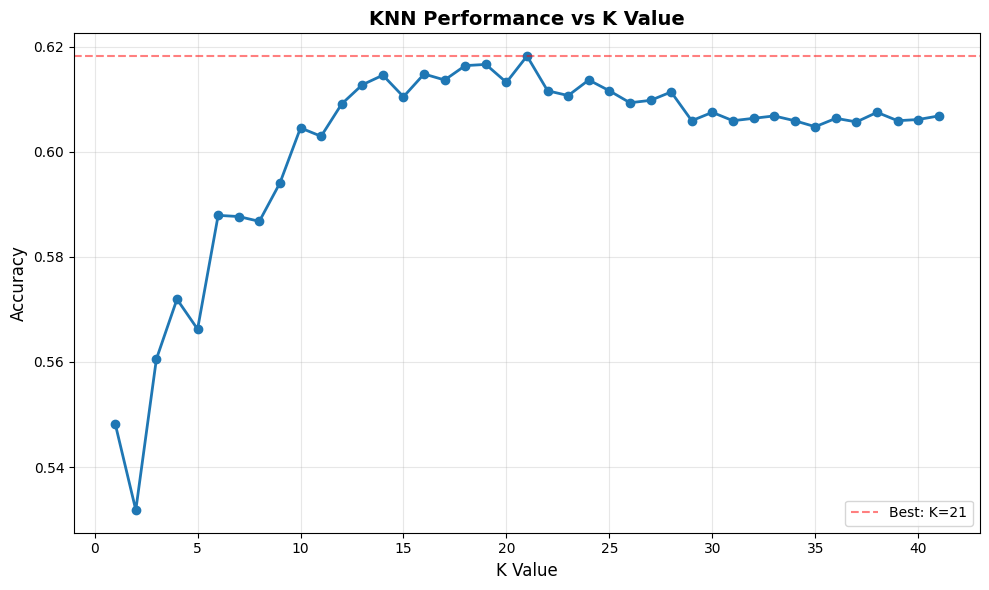

In [23]:
# Visualize KNN performance across different K values
import matplotlib.pyplot as plt

knn_df_plot = pd.DataFrame(knn_results)

plt.figure(figsize=(10, 6))
plt.plot(knn_df_plot['k'], knn_df_plot['accuracy'], marker='o', linewidth=2, markersize=6)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Performance vs K Value', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=best_knn['accuracy'], color='r', linestyle='--', alpha=0.5, label=f"Best: K={best_knn['k']}")
plt.legend()
plt.tight_layout()
plt.show()

knn confusion matrix

In [35]:
# Detailed evaluation of KNN (k=21) before comparing with other models
print("="*60)
print("DETAILED KNN EVALUATION (K=21)")
print("="*60)

# Train KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_knn['k'])
knn_best.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_knn = knn_best.predict(X_train_scaled)
y_test_pred_knn = knn_best.predict(X_test_scaled)

# Training and testing errors
train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)

print(f"\nTraining Accuracy: {train_accuracy_knn:.4f}")
print(f"Testing Accuracy: {test_accuracy_knn:.4f}")
print(f"Difference (Overfitting check): {train_accuracy_knn - test_accuracy_knn:.4f}")

if train_accuracy_knn - test_accuracy_knn > 0.1:
    print("⚠️ Model may be overfitting (difference > 0.1)")
else:
    print("Model generalizes well")

DETAILED KNN EVALUATION (K=21)

Training Accuracy: 0.6396
Testing Accuracy: 0.6182
Difference (Overfitting check): 0.0214
Model generalizes well


visualize

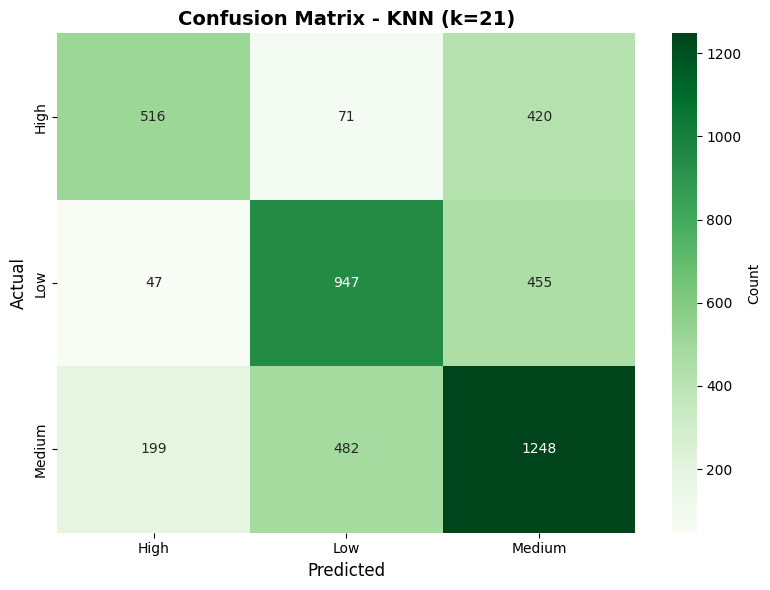


KNN Confusion Matrix Analysis:
High: 516/1007 correct (51.2%)
Low: 947/1449 correct (65.4%)
Medium: 1248/1929 correct (64.7%)


In [25]:
# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - KNN (k=21)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nKNN Confusion Matrix Analysis:")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):
    total = cm_knn[i].sum()
    correct = cm_knn[i, i]
    accuracy = correct / total * 100
    print(f"{class_name}: {correct}/{total} correct ({accuracy:.1f}%)")

knn classification report

In [26]:
# Detailed classification report for KNN
print("Classification Report - KNN (k=21)")
print("="*50)
print(classification_report(y_test, y_test_pred_knn,
                          target_names=label_encoder.classes_,
                          digits=4))

Classification Report - KNN (k=21)
              precision    recall  f1-score   support

        High     0.6772    0.5124    0.5834      1007
         Low     0.6313    0.6536    0.6423      1449
      Medium     0.5878    0.6470    0.6160      1929

    accuracy                         0.6182      4385
   macro avg     0.6321    0.6043    0.6139      4385
weighted avg     0.6227    0.6182    0.6172      4385



cross validation

5-Fold Cross-Validation - KNN (k=21)
Cross-validation scores: [0.59122007 0.59321551 0.59293044 0.59692132 0.58751425]
Mean accuracy: 0.5924
Standard deviation: 0.0031
95% confidence interval: [0.5864, 0.5983]


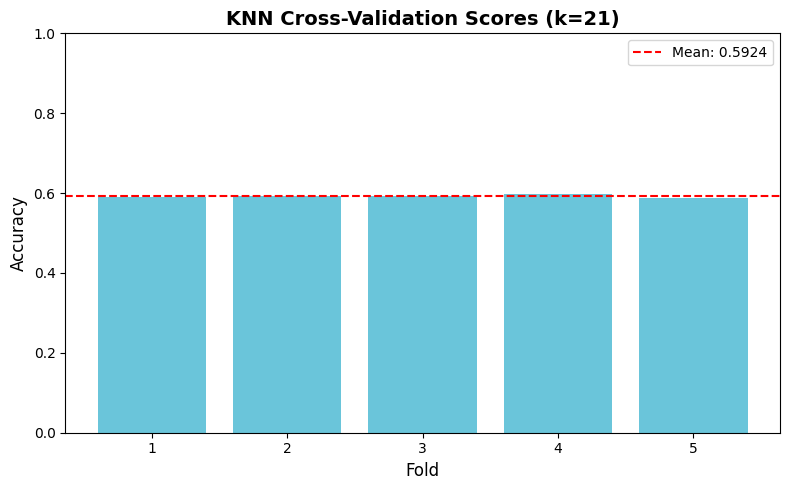

In [27]:
# Cross-validation for KNN
print("5-Fold Cross-Validation - KNN (k=21)")
print("="*50)

cv_scores_knn = cross_val_score(knn_best, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores_knn}")
print(f"Mean accuracy: {cv_scores_knn.mean():.4f}")
print(f"Standard deviation: {cv_scores_knn.std():.4f}")
print(f"95% confidence interval: [{cv_scores_knn.mean() - 1.96*cv_scores_knn.std():.4f}, {cv_scores_knn.mean() + 1.96*cv_scores_knn.std():.4f}]")

# Visualize CV scores
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores_knn, color='#45B7D1', alpha=0.8)
plt.axhline(y=cv_scores_knn.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores_knn.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Cross-Validation Scores (k=21)', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.legend()
plt.tight_layout()
plt.show()

GRIDSEARCHCV KNN

In [28]:
from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING - GridSearchCV for KNN (ULTRA-FAST)")
print("="*60)

# MINIMAL parameter grid - test only key values
param_grid_knn = {
    'n_neighbors': [5, 11, 21],           # Only 3 values (best from our range)
    'weights': ['uniform', 'distance'],   # 2 options
    'metric': ['euclidean', 'manhattan']  # 2 options
}

print("\nSearching parameter combinations...")
print(f"Total combinations: 3 × 2 × 2 = 12")
print(f"With 3-fold CV: 12 × 3 = 36 model trainings")
print("This should take 30-60 seconds...\n")

# GridSearchCV
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(X_train_scaled, y_train)

# Results
print("\n" + "="*60)
print("GridSearchCV RESULTS:")
print("="*60)
print(f"Best parameters: {grid_knn.best_params_}")
print(f"Best CV score: {grid_knn.best_score_:.4f}")

# Test with best KNN model
y_pred_knn_tuned = grid_knn.best_estimator_.predict(X_test_scaled)
test_acc_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)

print(f"\nTest accuracy with tuned KNN: {test_acc_knn_tuned:.4f}")
print(f"Original KNN (k=21): 0.6182")
print(f"Improvement: {(test_acc_knn_tuned - 0.6182)*100:.2f}%")

HYPERPARAMETER TUNING - GridSearchCV for KNN (ULTRA-FAST)

Searching parameter combinations...
Total combinations: 3 × 2 × 2 = 12
With 3-fold CV: 12 × 3 = 36 model trainings
This should take 30-60 seconds...

Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearchCV RESULTS:
Best parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best CV score: 0.6116

Test accuracy with tuned KNN: 0.6239
Original KNN (k=21): 0.6182
Improvement: 0.57%


visualize

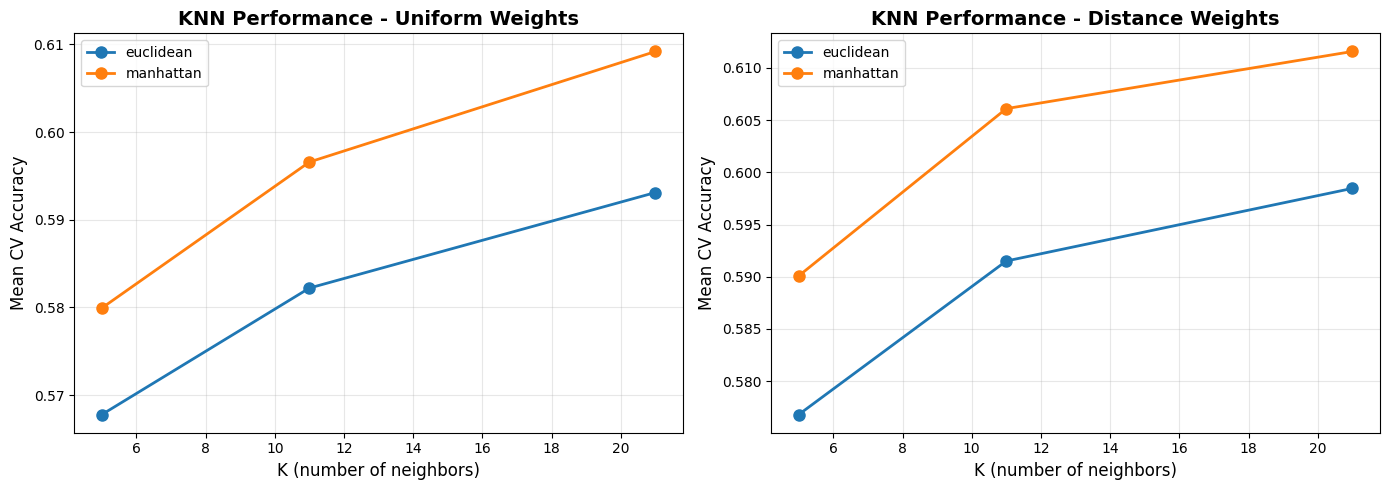


✓ Best configuration: K=21, weights=distance, metric=manhattan


In [29]:
# Visualize GridSearchCV results
results_df = pd.DataFrame(grid_knn.cv_results_)

# Plot accuracy vs K for different configurations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Uniform weights
for metric in ['euclidean', 'manhattan']:
    mask = (results_df['param_weights'] == 'uniform') & (results_df['param_metric'] == metric)
    data = results_df[mask].sort_values('param_n_neighbors')
    ax1.plot(data['param_n_neighbors'], data['mean_test_score'],
             marker='o', label=f'{metric}', linewidth=2, markersize=8)

ax1.set_xlabel('K (number of neighbors)', fontsize=12)
ax1.set_ylabel('Mean CV Accuracy', fontsize=12)
ax1.set_title('KNN Performance - Uniform Weights', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distance weights
for metric in ['euclidean', 'manhattan']:
    mask = (results_df['param_weights'] == 'distance') & (results_df['param_metric'] == metric)
    data = results_df[mask].sort_values('param_n_neighbors')
    ax2.plot(data['param_n_neighbors'], data['mean_test_score'],
             marker='o', label=f'{metric}', linewidth=2, markersize=8)

ax2.set_xlabel('K (number of neighbors)', fontsize=12)
ax2.set_ylabel('Mean CV Accuracy', fontsize=12)
ax2.set_title('KNN Performance - Distance Weights', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Best configuration: K={grid_knn.best_params_['n_neighbors']}, "
      f"weights={grid_knn.best_params_['weights']}, "
      f"metric={grid_knn.best_params_['metric']}")

confisuion matrix for tunned knn

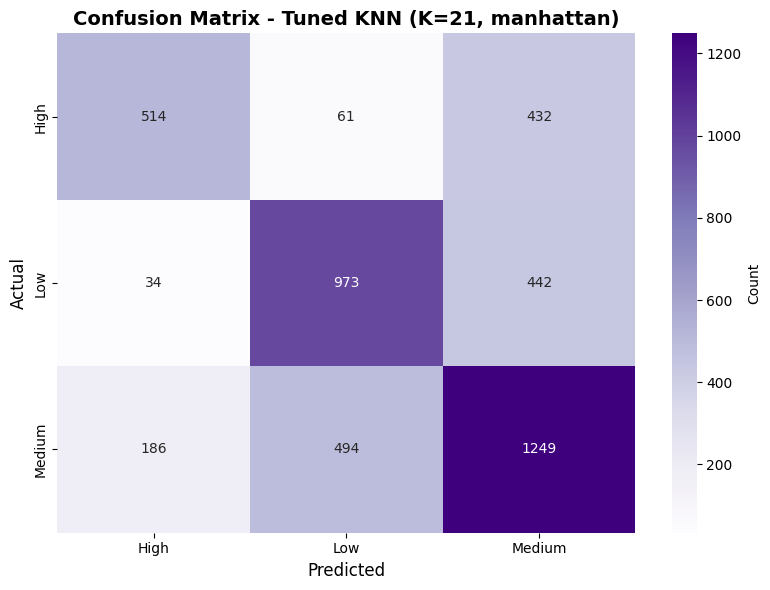

Tuned KNN Confusion Matrix Analysis:
High: 514/1007 correct (51.0%)
Low: 973/1449 correct (67.1%)
Medium: 1249/1929 correct (64.7%)


In [30]:
# Confusion matrix for tuned KNN
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - Tuned KNN (K={grid_knn.best_params_["n_neighbors"]}, {grid_knn.best_params_["metric"]})',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("Tuned KNN Confusion Matrix Analysis:")
print("="*50)
for i, class_name in enumerate(label_encoder.classes_):
    total = cm_knn_tuned[i].sum()
    correct = cm_knn_tuned[i, i]
    accuracy = correct / total * 100
    print(f"{class_name}: {correct}/{total} correct ({accuracy:.1f}%)")

classification matrix for tuned knn

In [31]:
# Classification report for tuned KNN
print("Classification Report - Tuned KNN")
print("="*50)
print(classification_report(y_test, y_pred_knn_tuned,
                          target_names=label_encoder.classes_,
                          digits=4))

Classification Report - Tuned KNN
              precision    recall  f1-score   support

        High     0.7003    0.5104    0.5905      1007
         Low     0.6368    0.6715    0.6537      1449
      Medium     0.5883    0.6475    0.6165      1929

    accuracy                         0.6239      4385
   macro avg     0.6418    0.6098    0.6202      4385
weighted avg     0.6300    0.6239    0.6228      4385




KNN COMPARISON:
                        KNN Version  Test Accuracy
Original (k=21, euclidean, uniform)       0.618200
  Tuned (k=21, manhattan, distance)       0.623945


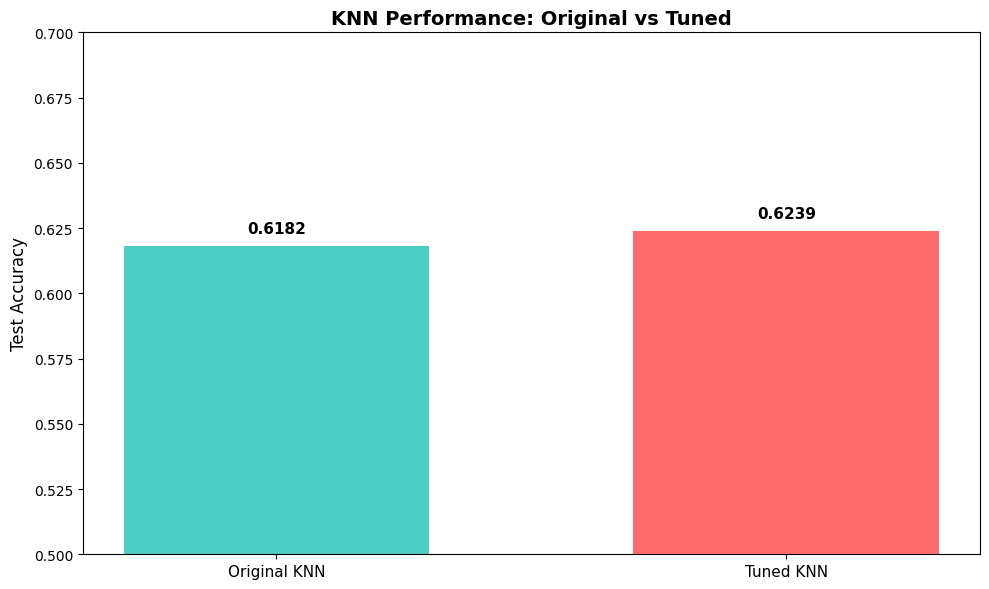


📈 Improvement from tuning: +0.57%


In [32]:
# Compare original vs tuned KNN
comparison_knn = pd.DataFrame({
    'KNN Version': [
        'Original (k=21, euclidean, uniform)',
        f'Tuned (k={grid_knn.best_params_["n_neighbors"]}, {grid_knn.best_params_["metric"]}, {grid_knn.best_params_["weights"]})'
    ],
    'Test Accuracy': [0.6182, test_acc_knn_tuned]
})

print("\n" + "="*60)
print("KNN COMPARISON:")
print("="*60)
print(comparison_knn.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(range(len(comparison_knn)), comparison_knn['Test Accuracy'],
        color=['#4ECDC4', '#FF6B6B'], width=0.6)
plt.xticks(range(len(comparison_knn)), ['Original KNN', 'Tuned KNN'], fontsize=11)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('KNN Performance: Original vs Tuned', fontsize=14, fontweight='bold')
plt.ylim([0.5, 0.7])
for i, v in enumerate(comparison_knn['Test Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n📈 Improvement from tuning: +{(test_acc_knn_tuned - 0.6182)*100:.2f}%")

pca analysis

PRINCIPAL COMPONENT ANALYSIS (PCA)

Original features: 18
Components for 90% variance: 14
Components for 95% variance: 16
Dimension reduction (95%): 18 → 16


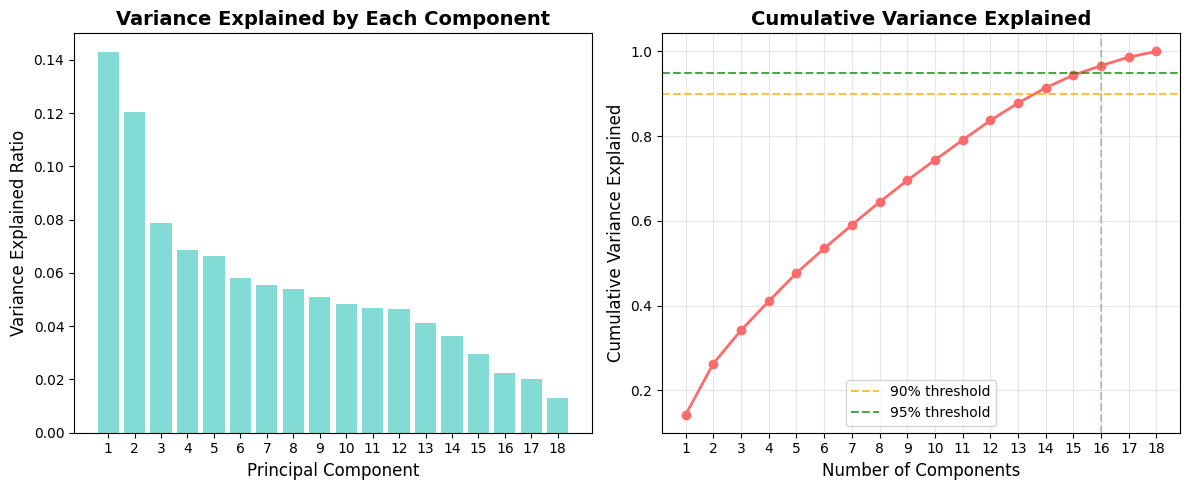


✓ Top 16 components capture 95% of variance
✓ Top 14 components capture 90% of variance


In [33]:
from sklearn.decomposition import PCA

print("="*60)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*60)

# Apply PCA to see variance explained
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative variance explained
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% and 90% variance
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1

print(f"\nOriginal features: {X_train_scaled.shape[1]}")
print(f"Components for 90% variance: {n_components_90}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Dimension reduction (95%): {X_train_scaled.shape[1]} → {n_components_95}")

# Visualize variance explained
plt.figure(figsize=(12, 5))

# Plot 1: Individual variance
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_, alpha=0.7, color='#4ECDC4')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained Ratio', fontsize=12)
plt.title('Variance Explained by Each Component', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Plot 2: Cumulative variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_variance)+1), cumsum_variance,
         marker='o', linewidth=2, markersize=6, color='#FF6B6B')
plt.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', alpha=0.3)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(cumsum_variance)+1))

plt.tight_layout()
plt.show()

print(f"\n✓ Top {n_components_95} components capture 95% of variance")
print(f"✓ Top {n_components_90} components capture 90% of variance")

train knn with pca

In [34]:
# Apply PCA transformation (use 95% variance threshold)
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Transformed data shape:")
print(f"  Original: {X_train_scaled.shape}")
print(f"  After PCA: {X_train_pca.shape}")
print(f"  Reduction: {X_train_scaled.shape[1] - n_components_95} features removed")

# Train best KNN model on PCA data
knn_pca = KNeighborsClassifier(**grid_knn.best_params_)
knn_pca.fit(X_train_pca, y_train)

# Evaluate
y_pred_knn_pca = knn_pca.predict(X_test_pca)
test_acc_knn_pca = accuracy_score(y_test, y_pred_knn_pca)

# Cross-validation on PCA data
cv_scores_pca = cross_val_score(knn_pca, X_train_pca, y_train, cv=5, scoring='accuracy')

print(f"\n" + "="*60)
print("PCA RESULTS:")
print("="*60)
print(f"Tuned KNN with all features ({X_train_scaled.shape[1]}): {test_acc_knn_tuned:.4f}")
print(f"Tuned KNN with PCA ({n_components_95} components): {test_acc_knn_pca:.4f}")
print(f"Difference: {(test_acc_knn_pca - test_acc_knn_tuned)*100:.2f}%")

print(f"\nCross-validation scores (PCA): {cv_scores_pca}")
print(f"Mean CV accuracy: {cv_scores_pca.mean():.4f} (±{cv_scores_pca.std():.4f})")

if test_acc_knn_pca >= test_acc_knn_tuned - 0.01:
    print(f"\n✓ PCA maintains performance with {X_train_scaled.shape[1] - n_components_95} fewer features!")
    print(f"  Benefits: Faster computation, reduced overfitting risk")
else:
    print(f"\n⚠️ PCA slightly reduces performance")
    print(f"  Trade-off: Simpler model vs {abs((test_acc_knn_pca - test_acc_knn_tuned)*100):.2f}% accuracy loss")

Transformed data shape:
  Original: (17540, 18)
  After PCA: (17540, 16)
  Reduction: 2 features removed

PCA RESULTS:
Tuned KNN with all features (18): 0.6239
Tuned KNN with PCA (16 components): 0.6146
Difference: -0.94%

Cross-validation scores (PCA): [0.60062714 0.5886545  0.59207526 0.59264538 0.59350057]
Mean CV accuracy: 0.5935 (±0.0039)

✓ PCA maintains performance with 2 fewer features!
  Benefits: Faster computation, reduced overfitting risk
